# Candidate Test 2022 Analysis Part 1

This exercise focuses on the candidate tests from two television networks: DR and TV2. Data from both tests have been given on a scale of five responses (-2, -1, 0, 1, 2).

---

There are 6 datasets included in this exercise:

- `alldata.xlsx`: Contains responses from both TV stations.
- `drdata.xlsx`: Contains responses from DR.
- `drq.xlsx`: Contains questions from DR.
- `tv2data.xlsx`: Contains responses from TV2.
- `tv2q.xlsx`: Contains questions from TV2.
- `electeddata.xlsx`: Contains responses from both TV stations for candidates who were elected to the parliament. Note that 9 members are missing; 7 of them didn't take any of the tests. Additionally, some notable figures like Mette F. and Lars Løkke did not participate in any of the tests.

---

It's entirely up to you how you approach this data, but at a *minimum*, your analysis should include:
- Age of the candidates grouped by parties.
- An overview of the most "confident" candidates, i.e., those with the highest proportion of "strongly agree" or "strongly disagree" responses.
- Differences in responses between candidates, both inter-party and intra-party, along with an explanation of which parties have the most internal disagreements.
- Classification models to predict candidates' party affiliations. Investigate if there are any candidates who seem to be in the "wrong" party based on their political landscape positions. You must use the following  algorithms: **Decision Tree**, **Random Forest** and **Gradient Boosted Tree**, i.e. a total of 3 models are to be trained.

---

The following parties are represented:

| Party letter | Party name | Party name (English) | Political position |
| :-: | :-: | :-: | :-: |
| A | Socialdemokratiet | Social Democrats | Centre-left |
| V | Venstre | Danish Liberal Party | Centre-right |
| M | Moderaterne | Moderates | Centre-right |
| F | Socialistisk Folkeparti | Socialist People's Party | Left-wing |
| D | Danmarksdemokraterne | Denmark Democrats | Right-wing |
| I | Liberal Alliance | Liberal Alliance | Right-wing |
| C | Konservative | Conservative People's Party | Right-wing |
| Æ | Enhedslisten | Red-Green Alliance | Far-left |
| B | Radikale Venstre | Social Liberal Party | Centre-left |
| D | Nye Borgerlige | New Right | Far-right |
| Z | Alternativet | The Alternative | Centre-left |
| O | Dansk Folkeparti | Danish People's Party | Far-right |
| G | Frie Grønne | Free Greens | Centre-left |
| K | Kristendemokraterne | Christian Democrats | Centre-right |

Below you can see the results and the colors chosen to represent the parties. Use these colors in your analysis above.

![Alt text](image-1.png)


Others have undertaken similar analyses. You can draw inspiration from the following (use Google tranlsate if your Danish is rusty):

- [Analysis of where individual candidates stand relative to each other and their parties](https://v2022.dumdata.dk/)
- [Candidate Test 2022 – A deep dive into the data](https://kwedel.github.io/kandidattest2022/)
- [The Political Landscape 2019](https://kwedel.github.io/kandidattest2019/)



In [1]:
import pandas as pd
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns

#questions are irrelevant rn
alldata = pd.read_excel("alldata.xlsx")
dr = pd.read_excel("drdata.xlsx")
elected = pd.read_excel("electeddata.xlsx")
tv2= pd.read_excel("tv2data.xlsx")

party_colors = {
    "Alternativet": "#2C903B",
    "Danmarksdemokraterne": "#8CC1FB",
    "Dansk Folkeparti": "#F3C946",
    "Det Konservative Folkeparti": "#9EBA29",
    "Enhedslisten": "#ED8019",
    "Frie Grønne, Danmarks Nye Venstrefløjsparti": "#2C903B",
    "Kristendemokraterne": "#D9D9D9",
    "Liberal Alliance": "#23C3CD",
    "Løsgænger": "#444444",
    "Moderaterne": "#6C38E5",
    "Nye Borgerlige": "#054F5C",
    "Radikale Venstre": "#733581",
    "Socialdemokratiet": "#B32722",
    "Socialistisk Folkeparti": "#DC0778",
    "Venstre": "#006696",
    "Løsgænger": "#555194"
}
#configure the colors to represent the image above.
party_labels = party_colors.keys()

colors = [party_colors.get(p, "#888888") for p in party_labels]


In [2]:
#Put nan where 0 and then fill with avg age
alldata["alder"] = alldata["alder"].replace(0, np.nan)
alldata["alder"] = alldata["alder"].fillna(alldata["alder"].mean())

In [3]:
elected["alder"] = elected["alder"].replace(0, np.nan)
elected["alder"] = elected["alder"].fillna(elected["alder"].mean())
tv2["alder"] = tv2["alder"].replace(0, np.nan)
tv2["alder"] = tv2["alder"].fillna(tv2["alder"].mean())
tv2

,1a,1b,2a,2b,3a,3b,4a,4b,5a,5b,...,10a,10b,11a,11b,12a,12b,parti,navn,storkreds,alder
0,0,1,1,1,1,-1,0,1,0,0,...,0,2,-1,2,0,0,Venstre,Birthe Tindbæk Bredo,Bornholms Storkreds,63.0
1,-1,1,0,-1,2,-2,-1,-1,-2,1,...,1,-1,-1,2,1,-1,Venstre,Julie Pauch Nymark,Bornholms Storkreds,27.0
2,-2,0,0,1,1,-1,0,1,-1,1,...,1,1,-2,2,1,1,Venstre,Peter Juel-Jensen,Bornholms Storkreds,56.0
3,-2,-1,2,2,2,-2,0,-1,-2,1,...,1,-1,-2,2,2,-2,Dansk Folkeparti,Mette Sode Hansen,Bornholms Storkreds,42.0
4,-2,-1,1,1,2,-2,1,0,-1,1,...,2,1,-1,2,0,1,Dansk Folkeparti,René Danielsson,Bornholms Storkreds,35.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
957,2,2,2,2,-2,2,2,-2,-2,1,...,-1,2,-2,2,0,0,"Frie Grønne, Danmarks Nye Venstrefløjsparti",Karina Dammand,Østjyllands Storkreds,42.0
958,2,2,2,2,-2,2,2,2,-2,-1,...,-2,2,-2,2,-2,-2,"Frie Grønne, Danmarks Nye Venstrefløjsparti",Mohamed Abdikarim,Østjyllands Storkreds,33.0
959,2,2,2,2,-2,2,2,1,-2,0,...,1,2,-1,2,1,1,"Frie Grønne, Danmarks Nye Venstrefløjsparti",Niko Grünfeld,Østjyllands Storkreds,47.0
960,1,2,2,1,-2,1,2,0,-1,0,...,2,1,-2,2,1,0,"Frie Grønne, Danmarks Nye Venstrefløjsparti",Sara Hvidbak Grouleff,Østjyllands Storkreds,33.0


In [4]:
alldata_avg_age_party = alldata.groupby("parti")["alder"].mean()
alldata_avg_age_party

parti
Alternativet                                   47.334374
Danmarksdemokraterne                           51.216216
Dansk Folkeparti                               45.530612
Det Konservative Folkeparti                    44.722511
Enhedslisten                                   42.325738
Frie Grønne, Danmarks Nye Venstrefløjsparti    34.807692
Kristendemokraterne                            50.088132
Liberal Alliance                               38.162901
Løsgænger                                      48.000000
Moderaterne                                    44.261905
Nye Borgerlige                                 48.445128
Radikale Venstre                               44.955224
Socialdemokratiet                              45.372449
Socialistisk Folkeparti                        41.567165
Venstre                                        46.678571
Name: alder, dtype: float64

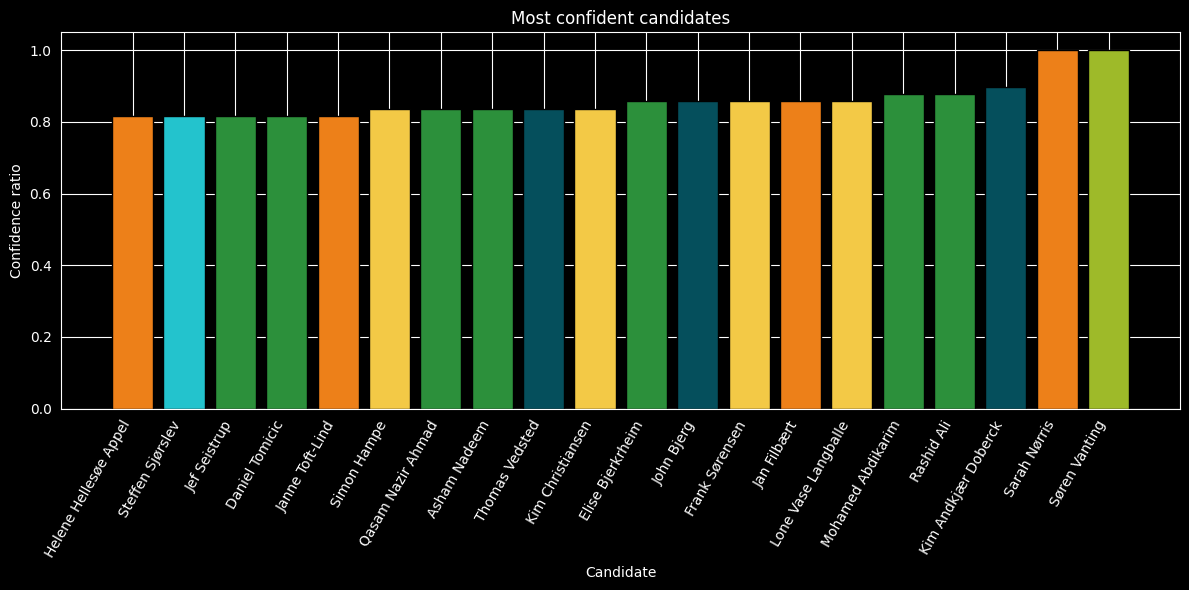

In [5]:
cols_without_questions = ["navn", "parti", "storkreds", "alder"]
question_cols = [c for c in alldata.columns if c not in cols_without_questions]

alldata["confidence_ratio"] = (
    (alldata[question_cols] == 2) | (alldata[question_cols] == -2)
).mean(axis = 1)

top_confident = alldata[["navn", "parti", "confidence_ratio"]].sort_values(
    "confidence_ratio", ascending=False
)
party_confidence = (
    top_confident.groupby("parti")["confidence_ratio"]
    .mean()
    .sort_values(ascending=False)
)

# Top 20 most confident candidates
top_n = 20
top_confident_n = top_confident.head(top_n).sort_values("confidence_ratio") #head is navn

# get party color for each candidate
candidate_colors = [
    party_colors.get(p, "#888888") for p in top_confident_n["parti"]
]

plt.figure(figsize=(12,6))

plt.bar(
    top_confident_n["navn"],
    top_confident_n["confidence_ratio"],
    color=candidate_colors,
    edgecolor="black"
)

plt.xlabel("Candidate")
plt.ylabel("Confidence ratio")
plt.title("Most confident candidates")

plt.xticks(rotation=60, ha="right")

plt.tight_layout()
plt.show()

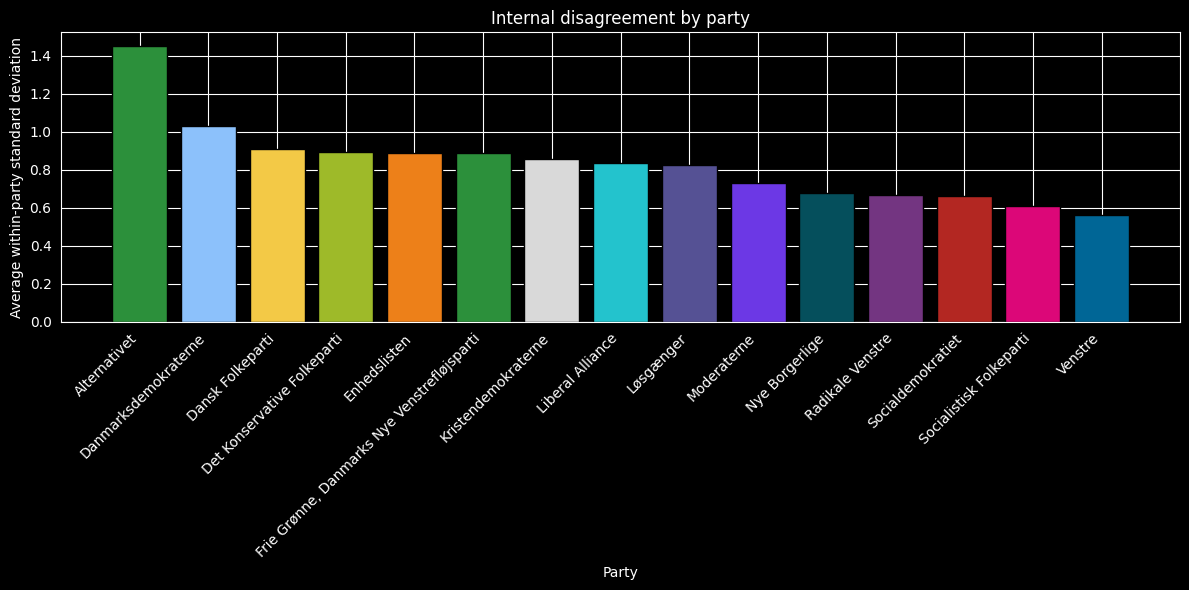

In [6]:
intra_party_disagreement = (
    alldata.groupby("parti")[question_cols]
    .std() #standard diviation
    .mean(axis=1)
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

plt.bar(
    party_labels,
    intra_party_disagreement.values,
    color=colors,
    edgecolor="black"
)

plt.xlabel("Party")
plt.ylabel("Average within-party standard deviation")
plt.title("Internal disagreement by party")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


### From the data set analyzed the party with most internal disagreements is Losgaenger, evaluated by the standard diviation compared to the mean value
In other words, we take the mean value of the party responses and see how much they fluctuate depending on each candidate and we average that fluctuation

big fluctuation = big divide

small fluctuation = little divide


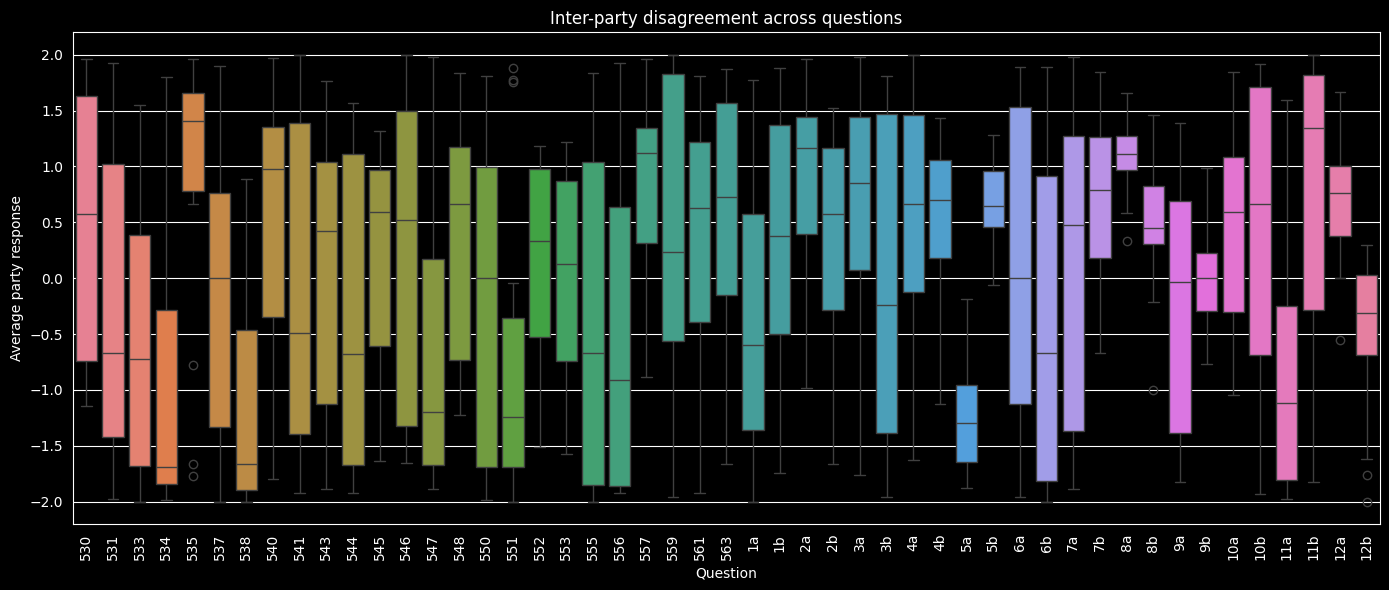

In [7]:
party_profiles = alldata.groupby("parti")[question_cols].mean()
plt.figure(figsize=(14,6))

sns.boxplot(data=party_profiles)

plt.xlabel("Question")
plt.ylabel("Average party response")
plt.title("Inter-party disagreement across questions")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Decision trees and predictions

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
data = alldata[question_cols]
labels = alldata["parti"]

X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

In [9]:
# train a decision tree classifier
tree_clf = DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_leaf=5)
tree_clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [10]:
# evaluate the model on the train set
train_accuracy = tree_clf.score(X_train, y_train)
print(f"Train set accuracy: {train_accuracy:.2f}")
# evaluate the model on the test set
accuracy = tree_clf.score(X_test, y_test)
print(f"Test set accuracy: {accuracy:.2f}")

Train set accuracy: 0.76
Test set accuracy: 0.74


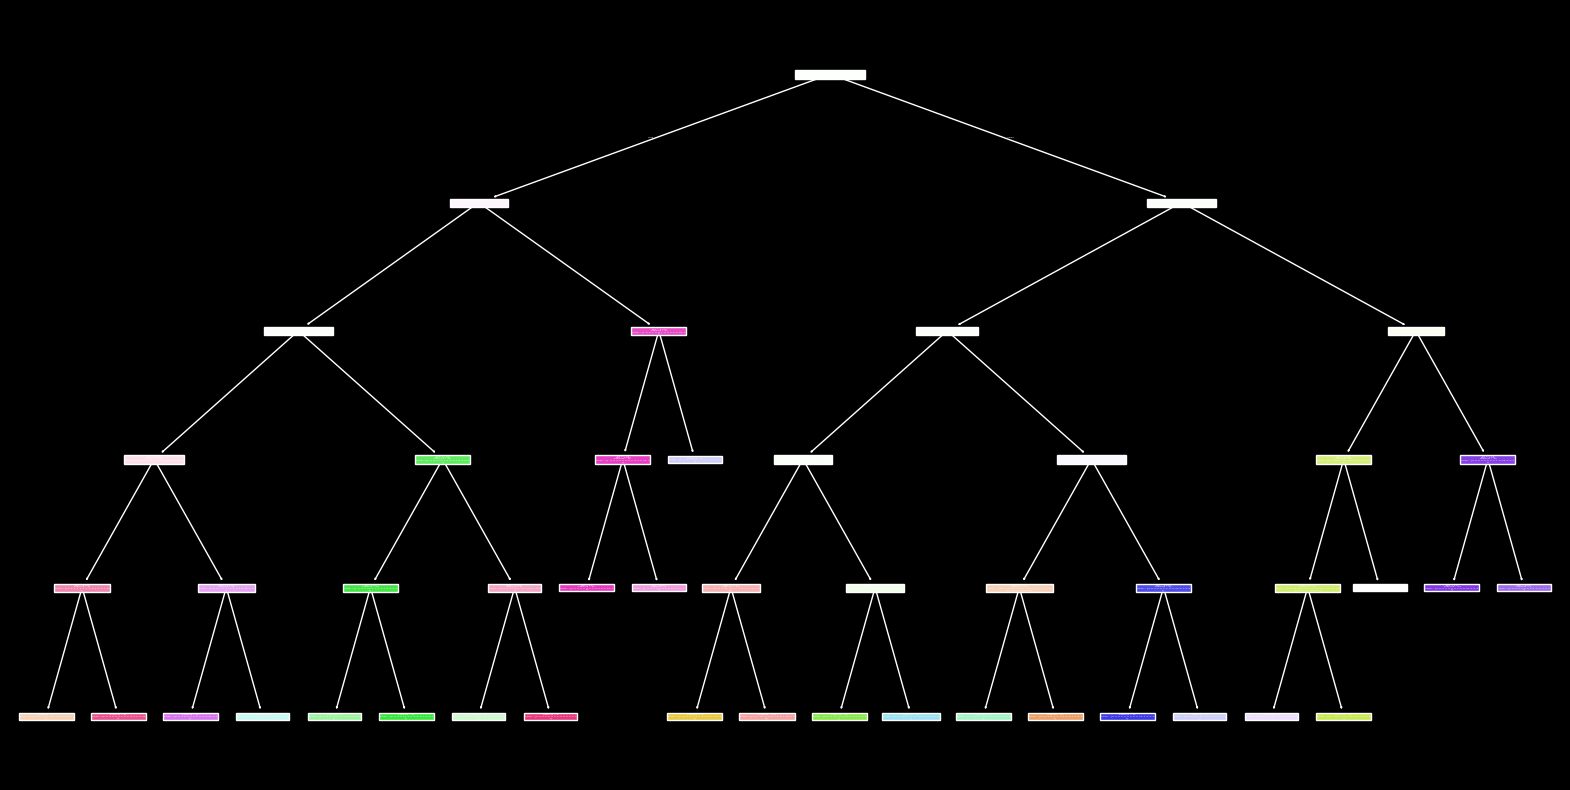

In [11]:
plt.figure(figsize=(20, 10))
plot_tree(tree_clf, filled=True, feature_names=X_train.columns)
plt.show()

In [12]:
# train a random forest classifier
n_features = X_train.shape[1]

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42, max_features=int(np.sqrt(n_features)))
rf_clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",7
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_true,

In [13]:
# evaluate the random forest on the train set
train_accuracy_rf = rf_clf.score(X_train, y_train)
print(f"Train set accuracy of random forest: {train_accuracy_rf:.2f}")
# evaluate the random forest on the test set
accuracy_rf = rf_clf.score(X_test, y_test)
print(f"Test set accuracy of random forest: {accuracy_rf:.2f}")

# feature importance from the random forest
feature_importances = rf_clf.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": data.columns,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)
print(feature_importance_df)

Train set accuracy of random forest: 0.89
Test set accuracy of random forest: 0.89
   Feature  Importance
3      534    0.069766
20     556    0.057351
46     11b    0.055782
1      531    0.052296
13     547    0.050924
7      540    0.047618
4      535    0.047323
35      6a    0.046861
44     10b    0.042579
36      6b    0.041863
45     11a    0.038837
19     555    0.038479
30      3b    0.031842
5      537    0.030525
16     551    0.025711
6      538    0.022173
12     546    0.020419
29      3a    0.020349
15     550    0.019125
31      4a    0.018245
37      7a    0.017389
11     545    0.016241
22     559    0.014692
9      543    0.014634
10     544    0.013097
2      533    0.013019
14     548    0.012293
28      2b    0.011020
0      530    0.010801
23     561    0.010767
27      2a    0.009040
40      8b    0.007177
26      1b    0.006830
25      1a    0.006825
21     557    0.006579
24     563    0.006345
18     553    0.005702
41      9a    0.005690
48     12b    0.0051

In [14]:
# train a gradient boosting classifier
gb_clf = GradientBoostingClassifier(n_estimators=10, max_depth=3, random_state=42)
gb_clf.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",10
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, `

In [15]:
# evaluate the gradient boosting classifier on the train set
train_accuracy_gb = gb_clf.score(X_train, y_train)
print(f"Train set accuracy of gradient boosting: {train_accuracy_gb:.2f}")
# evaluate the gradient boosting classifier on the test set
accuracy_gb = gb_clf.score(X_test, y_test)
print(f"Test set accuracy of gradient boosting: {accuracy_gb:.2f}")

Train set accuracy of gradient boosting: 0.96
Test set accuracy of gradient boosting: 0.86
